## Ethic/Bias Analysis

Goal of this notebook: conduct ethic/bias analysis to understand if our classification/segmentation models are being fair based on race, sex, and citizenship

Major sections:
1. Read classification/segmentation result
2. Selection Rate & Impact Ratio analysis
3. Model results plots vs. ethics features


Refer to Reports.pdf and decisions.md for detailed findings and decision making process.


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split



pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)
SEED = 42

### Read modeling results

In [ ]:
df_full = pd.read_parquet(DATA_DIR / "df_loaded.parquet")

# Re-derive the test indices using the same split parameters
indices = np.arange(len(df_full))
_, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=df_full["y"],
    random_state=SEED,
)

protected = df_full.iloc[test_idx][["sex", "race", "hispanic origin", "citizenship"]].reset_index(drop=True)

# Load scored test set produced by classification task
scored = pd.read_parquet(DATA_DIR / "test_scored.parquet").reset_index(drop=True)

# Use the F1-optimal threshold from classification
THRESHOLD = 0.85
scored["y_pred"] = (scored["winner_score"] >= THRESHOLD).astype(int)

fair_df = pd.concat([scored, protected], axis=1)
print(fair_df[["sex", "race", "hispanic origin", "citizenship"]].head())

      sex                         race     hispanic origin                                  citizenship
0  Female  Amer Indian Aleut or Eskimo           All other            Native- Born in the United States
1  Female                        White        Puerto Rican  Native- Born in Puerto Rico or U S Outlying
2    Male                        White           All other            Native- Born in the United States
3    Male                        White           All other            Native- Born in the United States
4  Female                        White  Mexican (Mexicano)           Foreign born- Not a citizen of U S


### Selection rate and impact ratio analysis

In [15]:
def selection_rate_table(df, group_col, score_col="y_pred", weight_col="weight"):
    rows = []
    for grp, sub in df.groupby(group_col):
        w = sub[weight_col].sum()
        selected_w = (sub[score_col] * sub[weight_col]).sum()
        rate = selected_w / w
        rows.append({"group": grp, "n_sample": len(sub), "pop_share": w, "selection_rate": rate})
    out = pd.DataFrame(rows).set_index("group")
    out["pop_share"] = out["pop_share"] / out["pop_share"].sum()

    # Disparate impact ratio relative to highest-selected group
    max_rate = out["selection_rate"].max()
    out["disparate_impact_ratio"] = out["selection_rate"] / max_rate
    return out.round(3)

for attr in ["sex", "race", "hispanic origin", "citizenship"]:
    print(f"\n=== Selection rate by {attr} ===")
    print(selection_rate_table(fair_df, attr))


=== Selection rate by sex ===
        n_sample  pop_share  selection_rate  disparate_impact_ratio
group                                                              
Female     20837      0.512           0.018                   0.154
Male       19068      0.488           0.115                   1.000

=== Selection rate by race ===
                             n_sample  pop_share  selection_rate  disparate_impact_ratio
group                                                                                   
Amer Indian Aleut or Eskimo       437      0.006           0.046                   0.595
Asian or Pacific Islander        1158      0.025           0.078                   1.000
Black                            4097      0.128           0.016                   0.201
Other                             729      0.011           0.014                   0.181
White                           33484      0.829           0.073                   0.937

=== Selection rate by hispanic origin ===

In [16]:
def performance_by_group(df, group_col):
    rows = []
    for grp, sub in df.groupby(group_col):
        if (sub["y_true"] == 1).sum() < 30:   # skip groups too small for stable estimates
            continue
        tpr = ((sub["y_pred"] == 1) & (sub["y_true"] == 1)).sum() / max((sub["y_true"] == 1).sum(), 1)
        fpr = ((sub["y_pred"] == 1) & (sub["y_true"] == 0)).sum() / max((sub["y_true"] == 0).sum(), 1)
        precision = ((sub["y_pred"] == 1) & (sub["y_true"] == 1)).sum() / max((sub["y_pred"] == 1).sum(), 1)
        rows.append({
            "group": grp, "n": len(sub),
            "TPR (recall)": tpr, "FPR": fpr, "precision": precision,
        })
    return pd.DataFrame(rows).set_index("group").round(3)

for attr in ["sex", "race"]:
    print(f"\n=== Performance by {attr} ===")
    print(performance_by_group(fair_df, attr))


=== Performance by sex ===
            n  TPR (recall)    FPR  precision
group                                        
Female  20837         0.397  0.007      0.577
Male    19068         0.698  0.047      0.630

=== Performance by race ===
                               n  TPR (recall)    FPR  precision
group                                                           
Asian or Pacific Islander   1158         0.558  0.027      0.646
Black                       4097         0.330  0.009      0.493
White                      33484         0.653  0.028      0.627


### Model results plots vs. ethics features

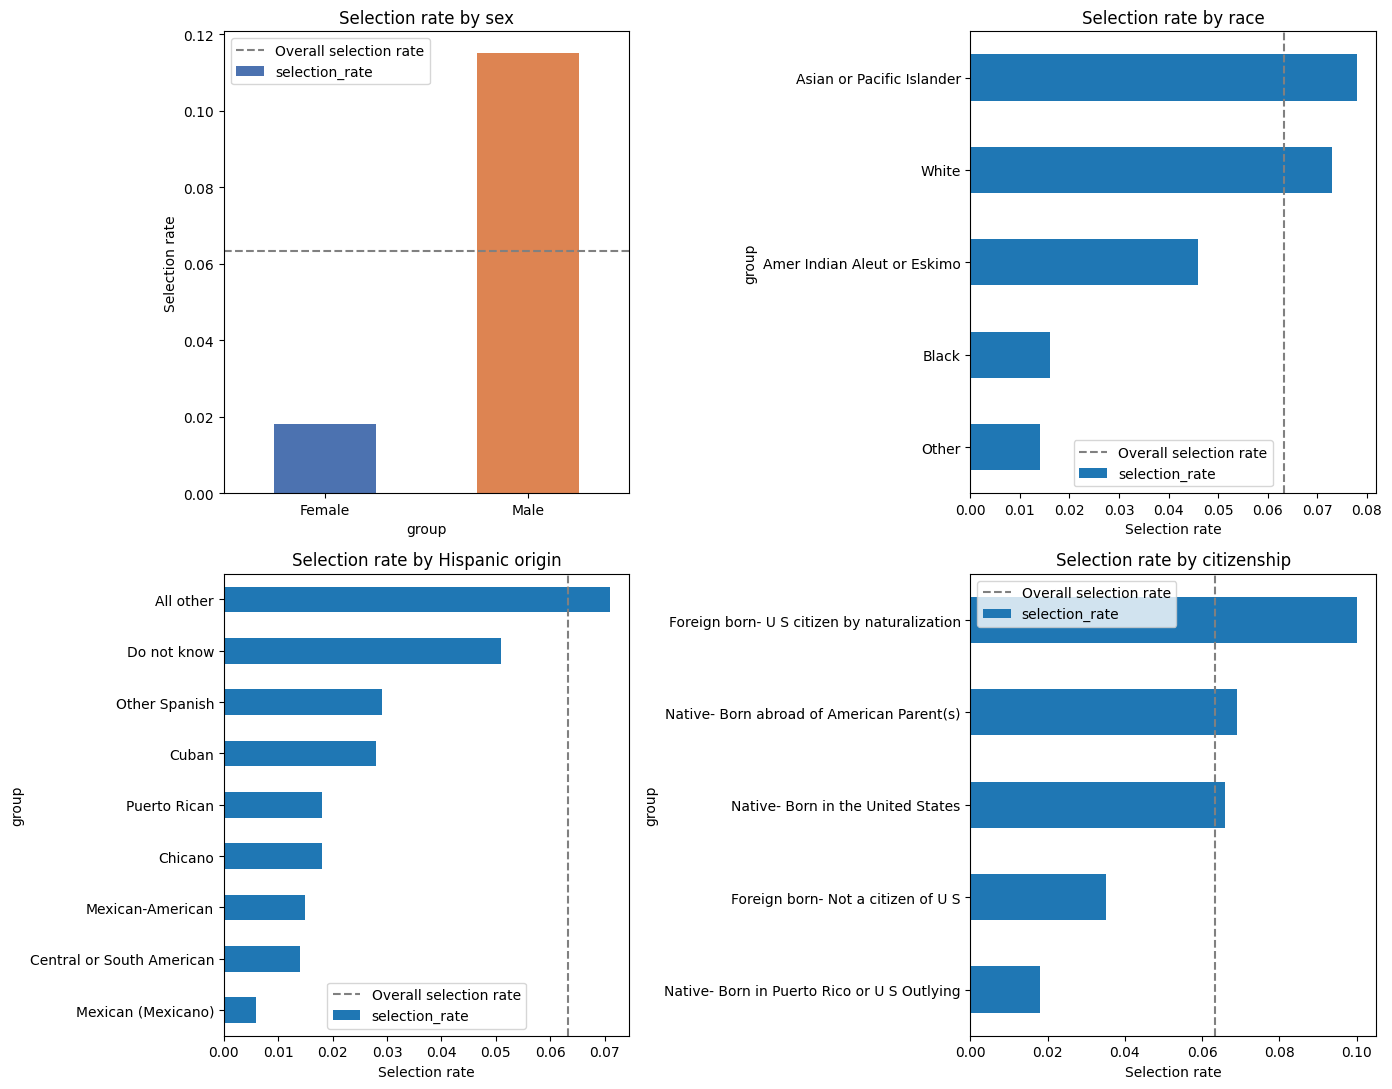

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
overall_rate = fair_df["y_pred"].mean()

# Sex 
sex_tab = selection_rate_table(fair_df, "sex")
sex_tab["selection_rate"].plot(kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452"])
axes[0, 0].axhline(overall_rate, ls="--", color="gray", label="Overall selection rate")
axes[0, 0].set_ylabel("Selection rate")
axes[0, 0].set_title("Selection rate by sex")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend()

# Race 
race_tab = selection_rate_table(fair_df, "race")
race_tab["selection_rate"].sort_values().plot(kind="barh", ax=axes[0, 1])
axes[0, 1].axvline(overall_rate, ls="--", color="gray", label="Overall selection rate")
axes[0, 1].set_xlabel("Selection rate")
axes[0, 1].set_title("Selection rate by race")
axes[0, 1].legend()

# Hispanic origin 
hisp_tab = selection_rate_table(fair_df, "hispanic origin")
hisp_tab["selection_rate"].sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].axvline(overall_rate, ls="--", color="gray", label="Overall selection rate")
axes[1, 0].set_xlabel("Selection rate")
axes[1, 0].set_title("Selection rate by Hispanic origin")
axes[1, 0].legend()

# Citizenship 
cit_tab = selection_rate_table(fair_df, "citizenship")
cit_tab["selection_rate"].sort_values().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].axvline(overall_rate, ls="--", color="gray", label="Overall selection rate")
axes[1, 1].set_xlabel("Selection rate")
axes[1, 1].set_title("Selection rate by citizenship")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "fairness_selection_rate.png", dpi=150, bbox_inches="tight")
plt.show()